Bonus

Implement ResNet-34

In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F


In [29]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import scipy.io

In [30]:
import os
os.chdir("/content/drive/MyDrive/Flower")


In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
labels = scipy.io.loadmat("/content/drive/MyDrive/Flower/imagelabels.mat")["labels"][0]
setid = scipy.io.loadmat("/content/drive/MyDrive/Flower/setid.mat")

train_ids = setid["trnid"].flatten() - 1
val_ids   = setid["valid"].flatten() - 1
test_ids  = setid["tstid"].flatten() - 1

print(len(train_ids), len(val_ids), len(test_ids))

1020 1020 6149


In [33]:
import scipy.io

setid = scipy.io.loadmat("setid.mat")
print("trnid shape:", setid["trnid"].shape)
print("valid shape:", setid["valid"].shape)
print("tstid shape:", setid["tstid"].shape)

trnid shape: (1, 1020)
valid shape: (1, 1020)
tstid shape: (1, 6149)


In [34]:
#Model preprocessing, transformation, Data Augmentation
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225]),])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225]),])

In [35]:
class FlowersDataset(torch.utils.data.Dataset):
    def __init__(self, ids, labels, transform=None, image_folder="/content/drive/MyDrive/Flower/images"):
        self.ids = ids
        self.labels = labels
        self.transform = transform
        self.image_folder = image_folder

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        image_id = self.ids[idx]
        img_path = os.path.join(self.image_folder, f"image_{image_id+1:05d}.jpg")
        image = Image.open(img_path).convert("RGB")
        label = self.labels[image_id] - 1

        if self.transform:
            image = self.transform(image)

        return image, label


In [36]:

image_folder = "/content/drive/MyDrive/Flower/images"

train_dataset = FlowersDataset(train_ids, labels, transform=train_transform, image_folder=image_folder)
val_dataset   = FlowersDataset(val_ids, labels, transform=val_transform, image_folder=image_folder)
test_dataset  = FlowersDataset(test_ids, labels, transform=val_transform, image_folder=image_folder)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [37]:
#Model Implementation

def convolution(in_channels, out_channels, stride=1):
    return nn.Conv2d(in_channels,out_channels, kernel_size=3,stride=stride, padding=1, bias=False)


class BasicBlock(nn.Module):
    expansion_value = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = convolution(in_channels, out_channels, stride)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = convolution(out_channels, out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)


        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)
        return out


class ResNet34(nn.Module):
    def __init__(self, num_classes=1000):
        super(ResNet34, self).__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)


        self.layer1 = self.add_layer(64, 3)
        self.layer2 = self.add_layer(128, 4, stride=2)
        self.layer3 = self.add_layer(256, 6, stride=2)
        self.layer4 = self.add_layer(512, 3, stride=2)


        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * BasicBlock.expansion, num_classes)

    def add_layer(self, out_channels, blocks, stride=1):
        downsample = None


        if stride != 1 or self.in_channels != out_channels * BasicBlock.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

        layers = []
        layers.append(BasicBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels


        for _ in range(1, blocks):
            layers.append(BasicBlock(out_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x






In [38]:
model = ResNet34(num_classes=102)

In [41]:
import torch
import torch.nn as nn
import torch.optim as optim
import pickle

def train_resnet34_hyperparams_best_pkl(train_loader, val_loader, model_class, hyperparams_list, model_name="resnet34_flowers"):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    best_val_loss_overall = None
    best_model_overall = None
    best_hyperparams = None
    results = []

    for i, params in enumerate(hyperparams_list):
        lr = params.get('lr', 0.001)
        num_epochs = params.get('num_epochs', 10)
        batch_size = params.get('batch_size', 32)

        print(f"\nTraining with hyperparameters set {i+1}: LR={lr}, Batch Size={batch_size}, Epochs={num_epochs}")

        model = model_class(num_classes=102).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)

        history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

        for epoch in range(num_epochs):
            model.train()
            running_loss = 0.0
            correct = 0
            total = 0

            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

            train_loss_epoch = running_loss / total
            train_acc_epoch = correct / total

            model.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0

            with torch.no_grad():
                for val_inputs, val_labels in val_loader:
                    val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)

                    val_outputs = model(val_inputs)
                    loss = criterion(val_outputs, val_labels)

                    val_loss += loss.item() * val_inputs.size(0)
                    _, val_preds = torch.max(val_outputs, 1)
                    val_correct += (val_preds == val_labels).sum().item()
                    val_total += val_labels.size(0)

            val_loss_epoch = val_loss / val_total
            val_acc_epoch = val_correct / val_total

            history["train_loss"].append(train_loss_epoch)
            history["train_acc"].append(train_acc_epoch)
            history["val_loss"].append(val_loss_epoch)
            history["val_acc"].append(val_acc_epoch)

            print(f"Epoch [{epoch+1}/{num_epochs}] - "
                  f"Train Loss: {train_loss_epoch:.4f}, Train Acc: {train_acc_epoch:.4f}, "
                  f"Val Loss: {val_loss_epoch:.4f}, Val Acc: {val_acc_epoch:.4f}")

            if best_val_loss_overall is None or val_loss_epoch < best_val_loss_overall:
                best_val_loss_overall = val_loss_epoch
                best_model_overall = model
                best_hyperparams = params

                with open(f"{model_name}_best_weights.pkl", "wb") as f:
                    pickle.dump(model.state_dict(), f)

        results.append({"hyperparams": params, "history": history, "model": model})

    print(f"\nBest hyperparameters: {best_hyperparams}")
    return best_model_overall, best_hyperparams, results


In [43]:
hyperparams_list = [
    {"lr": 0.001, "batch_size": 32, "num_epochs": 150},
    {"lr": 0.0005, "batch_size": 32, "num_epochs": 100}
]

best_model, best_hyperparams, results = train_resnet34_hyperparams_best_pkl(
    train_loader=train_loader,
    val_loader=val_loader,
    model_class=ResNet34,
    hyperparams_list=hyperparams_list,
    model_name="resnet34_flowers"
)

Using device: cuda

Training with hyperparameters set 1: LR=0.001, Batch Size=32, Epochs=150
Epoch [1/150] - Train Loss: 4.8969, Train Acc: 0.0059, Val Loss: 4.7265, Val Acc: 0.0353
Epoch [2/150] - Train Loss: 4.3422, Train Acc: 0.0206, Val Loss: 4.6511, Val Acc: 0.0441
Epoch [3/150] - Train Loss: 4.1914, Train Acc: 0.0294, Val Loss: 4.1986, Val Acc: 0.0696
Epoch [4/150] - Train Loss: 4.0628, Train Acc: 0.0422, Val Loss: 4.1154, Val Acc: 0.0637
Epoch [5/150] - Train Loss: 4.0078, Train Acc: 0.0461, Val Loss: 4.4160, Val Acc: 0.0569
Epoch [6/150] - Train Loss: 3.8507, Train Acc: 0.0647, Val Loss: 3.7955, Val Acc: 0.0853
Epoch [7/150] - Train Loss: 3.8517, Train Acc: 0.0618, Val Loss: 3.7680, Val Acc: 0.0843
Epoch [8/150] - Train Loss: 3.7257, Train Acc: 0.0843, Val Loss: 3.7463, Val Acc: 0.1098
Epoch [9/150] - Train Loss: 3.6496, Train Acc: 0.0725, Val Loss: 3.7613, Val Acc: 0.1078
Epoch [10/150] - Train Loss: 3.5572, Train Acc: 0.0971, Val Loss: 3.7269, Val Acc: 0.1176
Epoch [11/150] -

In [46]:
import torch
import numpy as np
from sklearn.metrics import precision_recall_fscore_support
import time
import pickle


model = ResNet34(num_classes=102)
weights_path = "resnet34_flowers_best_weights.pkl"
with open(weights_path, "rb") as f:
    state_dict = pickle.load(f)

model.load_state_dict(state_dict)
model.eval()


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)



y_true = []
y_predictions = []
test_loss = 0.0
test_correct = 0
test_total = 0
criterion = torch.nn.CrossEntropyLoss()

start_time = time.time()

with torch.no_grad():
    for inputs, labels in test_loader:

        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * inputs.size(0)

        _, preds = torch.max(outputs, 1)
        y_predictions.extend(preds.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)

test_time = time.time() - start_time
test_accuracy = test_correct / test_total
test_loss = test_loss / test_total


y_true = np.array(y_true)
y_predictions = np.array(y_predictions)

precision, recall, f1_score, support = precision_recall_fscore_support(
    y_true, y_predictions, average='weighted', zero_division=0
)

print(f"\nTest Time: {test_time:.2f} seconds")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")


Contribution:

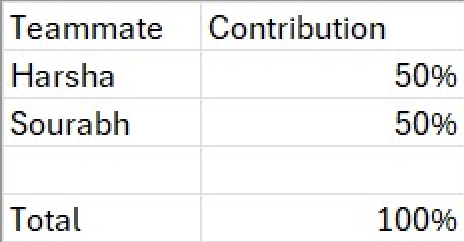

References:

Paper Regarding ResNet-34 architecture - https://www.cv-foundation.org/openaccess/content_cvpr_2016/papers/He_Deep_Residual_Learning_CVPR_2016_paper.pdf

Dataset used - https://www.robots.ox.ac.uk/~vgg/data/flowers/102/

Pytorch tutorials - https://pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html

Torchinfo - https://github.com/TylerYep/torchinfo

ROC Specifications - https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc

Python Docs ( For time calculation)- https://docs.python.org/3/library/time.html


